<a href="https://colab.research.google.com/github/thaynnayara/ADS-Inteligencia_Artificial/blob/main/basket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Você foi contratado como analista de dados por um supermercado de médio porte que deseja entender melhor o comportamento de compra de seus clientes. O objetivo da empresa é aumentar o ticket médio, melhorar o layout das gôndolas e planejar promoções combinadas com base em padrões reais de compra

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1 - Carregar o dataset do supermercado
df = pd.read_csv('basket_supermercado_1000.csv')

# Focando apenas no produto
df_itens = df.drop(columns=['transacao'])

In [4]:
# 2 - Análise exploratória dos itens mais vendidos
print("- 5 itens mais vendidos -")
print(df_itens.sum().sort_values(ascending=False).head(5))
print("-" * 50)

- 5 itens mais vendidos -
pao           633
leite         630
arroz         519
feijao        512
hortifruti    490
dtype: int64
--------------------------------------------------


#Análise:
Pão, Leite, Arroz e Feijão são produtos de alta necessidade. Servem como o principal fluxo de atração de clientes para dentro da loja.

In [5]:
# 3 - Função para calcular as métricas
def calcular_regras_associacao(df, min_suporte=0.05):
    total_transacoes = len(df)
    colunas = df.columns
    regras = []

    # Analisando pares de produtos (Item A -> Item B)
    for i in range(len(colunas)):
        for j in range(len(colunas)):
            if i == j:
                continue
            item_a = colunas[i]
            item_b = colunas[j]

            # individuais e conjuntos
            sup_a = df[item_a].sum() / total_transacoes
            sup_b = df[item_b].sum() / total_transacoes
            sup_conjunto = ((df[item_a] == 1) & (df[item_b] == 1)).sum() / total_transacoes

            # Suporte min
            if sup_conjunto >= min_suporte:
                confianca = sup_conjunto / sup_a if sup_a > 0 else 0
                lift = sup_conjunto / (sup_a * sup_b) if (sup_a * sup_b) > 0 else 0

                regras.append({
                    'Antecedente (Se compra)': item_a,
                    'Consequente (Leva também)': item_b,
                    'Suporte': round(sup_conjunto, 3),
                    'Confiança': round(confianca, 3),
                    'Lift': round(lift, 3)
                })

    return pd.DataFrame(regras)

# Regras de execução
df_regras = calcular_regras_associacao(df_itens, min_suporte=0.05)

# Ordenação
df_regras_fortes = df_regras.sort_values(by='Lift', ascending=False).reset_index(drop=True)

print("\n- Regras de associação identificadas -")
print(df_regras_fortes.head(10))


- Regras de associação identificadas -
  Antecedente (Se compra) Consequente (Leva também)  Suporte  Confiança   Lift
0                 cerveja              refrigerante    0.191      0.565  2.691
1            refrigerante                   cerveja    0.191      0.910  2.691
2                 cerveja                     doces    0.115      0.340  2.597
3                   doces                   cerveja    0.115      0.878  2.597
4                    cafe                    acucar    0.373      0.949  2.434
5                  acucar                      cafe    0.373      0.956  2.434
6                   doces              refrigerante    0.064      0.489  2.326
7            refrigerante                     doces    0.064      0.305  2.326
8                   arroz                    feijao    0.503      0.969  1.893
9                  feijao                     arroz    0.503      0.982  1.893


#Análise:
- A regra Cerveja -> Refrigerante possui o maior Lift (2,69). Significa que um cliente que compra cerveja tem 2,69 vezes mais chance de colocar um refrigerante no carrinho do que um cliente comum.

- A regra Arroz -> Feijão possui uma confiança muito boa (96,9%). Praticamente toda pessoa que compra arroz nesta base está levando feijão.

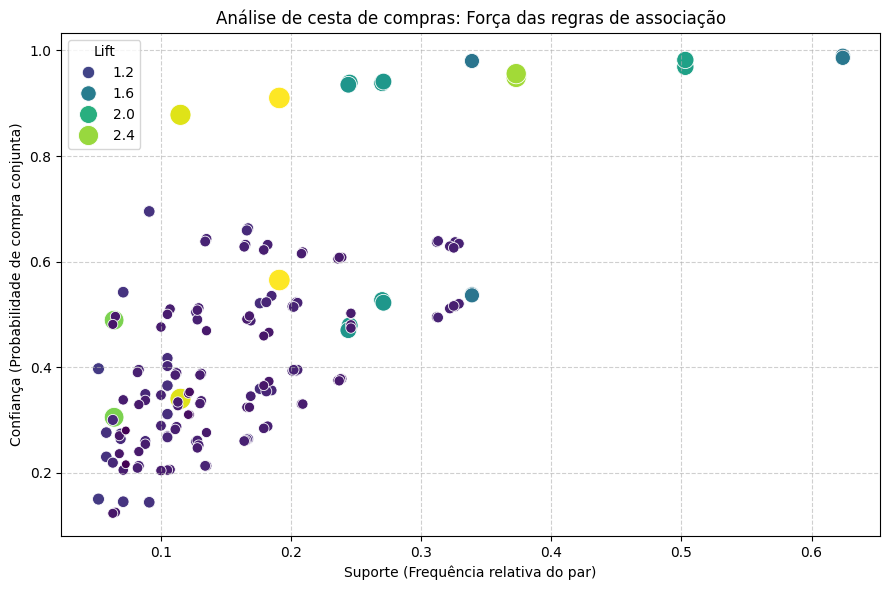

In [6]:
# 4 - Geração de gráfico de suporte vs confiança
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x="Suporte",
    y="Confiança",
    size="Lift",
    hue="Lift",
    palette="viridis",
    sizes=(40, 240),
    data=df_regras_fortes
)
plt.title("Análise de cesta de compras: Força das regras de associação")
plt.xlabel("Suporte (Frequência relativa do par)")
plt.ylabel("Confiança (Probabilidade de compra conjunta)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#Conclusões:
Como a confiança de compra conjunta entre Arroz/Feijão (96,9%) e Pão/Leite (98,5%) é extrema, não devem colocá-los lado a lado no mesmo corredor. O feijão deve ser posicionado a alguns metros de distância do arroz. O mesmo vale para o pão e o leite.

Cerveja + Refrigerante -> O alto Lift (2,69) aponta para compras focadas em eventos/finais de semana. O ideal é criar uma ilha promocional nas sextas-feiras associando marcas específicas. Exemplo: "Na compra de um fardo de Cerveja X, ganhe 20% de desconto no Refrigerante Y de 2 Litros".